<a href="https://colab.research.google.com/github/jacquelinechesher/QM2-real/blob/main/beginningCancerRates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
import seaborn as sns

import pylab
import pandas as pd
import numpy as np

pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.5)
sns.set_style("white")

In [20]:
cancer_df = pd.read_csv('QM2CancerRates.csv', header=None)
cancer_df.columns = cancer_df.iloc[8].values
cancer_df = cancer_df[11:]
cancer_df = cancer_df.reset_index(drop=True)
cancer_df['Parish'] = cancer_df['Parish'].str.replace('(7)', '', regex=False)
index = cancer_df[cancer_df['Parish'] == 'Lincoln Parish'].index[0]
cancer_df = cancer_df.iloc[:index + 1]
cancer_df.head()

,Parish,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval,Upper 95% Confidence Interval
0,Claiborne Parish,22027,Rural,315.8,275.6,360.7,1,1,39,50,rising,3.1,0.7,8.6
1,Iberville Parish,22047,Urban,314.8,287.3,344.3,2,1,21,106,rising,1.5,0.5,2.5
2,Cameron Parish,22023,Urban,307.9,245,382.9,3,1,64,19,stable,0.7,-1.8,2.9
3,St. Landry Parish,22097,Rural,298.6,281.4,316.7,4,1,23,249,rising,1.5,0.7,2.2
4,Red River Parish,22081,Rural,291.4,240.6,350.7,5,1,63,26,stable,1.6,-0.4,3.6


In [21]:
target_parishes = ['East Baton Rouge Parish', 'West Baton Rouge Parish', 'Iberville Parish', 'Ascension Parish', 'St. James Parish', 'St. John the Baptist Parish', 'St. Charles Parish', 'Jefferson Parish']
target_parishes_df = cancer_df[cancer_df['Parish'].isin(target_parishes)]
other_parishes_df = cancer_df[~cancer_df['Parish'].isin(target_parishes)]


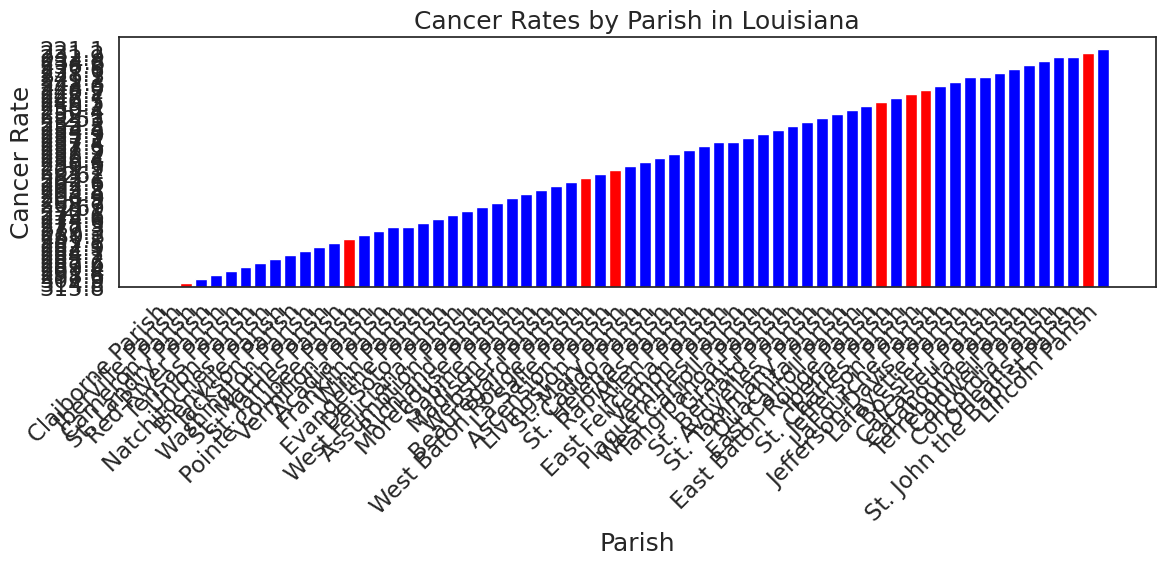

In [26]:
import matplotlib.pyplot as plt

target_parishes = ['East Baton Rouge Parish', 'West Baton Rouge Parish', 'Iberville Parish', 'Ascension Parish', 'St. James Parish', 'St. John the Baptist Parish', 'St. Charles Parish', 'Jefferson Parish']

colors = ['red' if parish in target_parishes else 'blue' for parish in cancer_df['Parish']]

plt.figure(figsize=(12, 6))
plt.bar(cancer_df['Parish'], cancer_df['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'], color=colors)
plt.xlabel('Parish')
plt.ylabel('Cancer Rate')
plt.title('Cancer Rates by Parish in Louisiana')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()